# LLVIP → YOLOv8 Fine-tune (Dark / Night Condition)

This notebook replaces the previous ExDark pseudo-label approach with the **LLVIP dataset**.

| Root cause of ExDark failure | How LLVIP fixes it |
|---|---|
| Only 609 images (People folder) | ~15,000 images total |
| Noisy pseudo-labels (ceiling-limited by baseline model) | Real human-annotated bounding boxes |
| Photography domain — poor match to CCTV footage | Actual dark street surveillance footage |
| Class imbalance (1 of 12 folders = persons) | 100% pedestrian-labelled dataset |

**Expected LLVIP folder structure after download:**
```
LLVIP/
  visible/
    train/    <- RGB dark street images   used
    test/     <- RGB dark street images   used as val
  infrared/
    train/    <- thermal IR images        skipped
    test/
  Annotations/
    train/    <- Pascal VOC XML labels    converted
    test/
```

> Only **visible** images are used. Infrared images are skipped because
> your surveillance pipeline uses a standard RGB camera.

## 0) Install Dependencies (run once)

In [ ]:
# Uncomment if needed:
# !pip install -q ultralytics opencv-python numpy tqdm pyyaml matplotlib

## 1) Configuration — Edit These Paths

In [15]:
import os, random, shutil, glob
from pathlib import Path
import yaml
from tqdm import tqdm

# ---------------------------------------------------------
# EDIT THESE
# ---------------------------------------------------------
LLVIP_ROOT    = "../LLVIP"              # root folder of LLVIP download
YOLO_OUT_ROOT = "runs/darkCondition_yolo" # output YOLO dataset (same as before)
BASE_WEIGHTS  = "yolov8n.pt"            # starting weights
SEED          = 42

# MAX images — LLVIP train has ~12,025 images.
# 6000 is enough for strong results on an RTX 4060 Laptop.
# Set None to use all images (better accuracy, slower).
MAX_TRAIN_IMAGES = 6000
MAX_VAL_IMAGES   = 1500

# ---------------------------------------------------------
# Derived paths — do not edit
# ---------------------------------------------------------
VIS_TRAIN_DIR = os.path.join(LLVIP_ROOT, "visible",     "train")
VIS_TEST_DIR  = os.path.join(LLVIP_ROOT, "visible",     "test")
ANN_DIR = os.path.join(LLVIP_ROOT, "Annotations")

ANN_TRAIN_DIR = ANN_DIR
ANN_TEST_DIR  = ANN_DIR

print("LLVIP_ROOT    :", LLVIP_ROOT)
print("YOLO_OUT_ROOT :", YOLO_OUT_ROOT)
print()

all_ok = True
for p in [VIS_TRAIN_DIR, VIS_TEST_DIR, ANN_TRAIN_DIR, ANN_TEST_DIR]:
    exists = os.path.exists(p)
    print(f"  {'OK' if exists else 'NOT FOUND'}  {p}")
    if not exists:
        all_ok = False

print()
if not all_ok:
    print("WARNING: Some folders missing — check LLVIP_ROOT path above.")
else:
    print("All LLVIP folders found. Ready to proceed.")

LLVIP_ROOT    : ../LLVIP
YOLO_OUT_ROOT : runs/darkCondition_yolo

  OK  ../LLVIP\visible\train
  OK  ../LLVIP\visible\test
  OK  ../LLVIP\Annotations
  OK  ../LLVIP\Annotations

All LLVIP folders found. Ready to proceed.


## 2) About LLVIP Annotations

LLVIP uses **Pascal VOC XML** format with real human-annotated bounding boxes.
No pseudo-labels are needed.

```xml
<annotation>
  <filename>010001.jpg</filename>
  <size><width>1280</width><height>1024</height></size>
  <object>
    <name>person</name>
    <bndbox>
      <xmin>430</xmin><ymin>280</ymin>
      <xmax>500</xmax><ymax>480</ymax>
    </bndbox>
  </object>
</annotation>
```

We convert each XML to YOLO format: `0 cx cy bw bh`
(class 0 = person, all coordinates normalised 0 to 1).

## 3) Convert LLVIP XML Annotations to YOLO Format

In [16]:
import xml.etree.ElementTree as ET
import cv2
import numpy as np


def ensure_dirs(out_root):
    for split in ("train", "val"):
        os.makedirs(os.path.join(out_root, "images", split), exist_ok=True)
        os.makedirs(os.path.join(out_root, "labels", split), exist_ok=True)


def parse_llvip_xml(xml_path):
    """
    Parse one LLVIP Pascal VOC XML.
    Returns: list of (xmin, ymin, xmax, ymax), img_w, img_h.
    Falls back to reading the actual image size if <size> tag is 0
    (this happens in a small number of LLVIP files).
    """
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size_tag = root.find("size")
    img_w = int(size_tag.find("width").text)  if size_tag is not None else 0
    img_h = int(size_tag.find("height").text) if size_tag is not None else 0

    boxes = []
    for obj in root.findall("object"):
        name_tag = obj.find("name")
        if name_tag is None:
            continue
        if name_tag.text.strip().lower() != "person":
            continue
        bb = obj.find("bndbox")
        xmin = float(bb.find("xmin").text)
        ymin = float(bb.find("ymin").text)
        xmax = float(bb.find("xmax").text)
        ymax = float(bb.find("ymax").text)
        boxes.append((xmin, ymin, xmax, ymax))

    return boxes, img_w, img_h


def xyxy_to_yolo(xmin, ymin, xmax, ymax, img_w, img_h):
    """Convert absolute (xmin,ymin,xmax,ymax) to normalised YOLO cx cy bw bh."""
    xmin = max(0.0, min(xmin, img_w - 1))
    xmax = max(0.0, min(xmax, img_w - 1))
    ymin = max(0.0, min(ymin, img_h - 1))
    ymax = max(0.0, min(ymax, img_h - 1))
    bw   = max(1.0, xmax - xmin)
    bh   = max(1.0, ymax - ymin)
    cx   = xmin + bw / 2.0
    cy   = ymin + bh / 2.0
    return cx / img_w, cy / img_h, bw / img_w, bh / img_h


def convert_split(img_dir, ann_dir, split_name, out_root,
                  max_images=None, seed=42):
    """
    Convert one LLVIP split (train or test) to YOLO format.
    Copies visible images and writes YOLO label .txt files.
    """
    img_paths = sorted(
        [str(p) for p in Path(img_dir).glob("*.jpg")] +
        [str(p) for p in Path(img_dir).glob("*.png")]
    )

    if not img_paths:
        print(f"  WARNING: No images found in {img_dir}")
        return 0, 0, 0

    if max_images is not None and len(img_paths) > max_images:
        random.seed(seed)
        img_paths = random.sample(img_paths, max_images)
        print(f"  Subsampled {split_name} to {max_images} images")

    total_imgs   = 0
    total_boxes  = 0
    empty_labels = 0
    skipped      = 0

    for img_path in tqdm(img_paths, desc=f"Converting {split_name}"):
        stem     = Path(img_path).stem
        xml_path = os.path.join(ann_dir, stem + ".xml")

        if not os.path.exists(xml_path):
            skipped += 1
            continue

        boxes, img_w, img_h = parse_llvip_xml(xml_path)

        # Fall back to reading image dimensions if <size> tag is missing/zero
        if img_w == 0 or img_h == 0:
            img = cv2.imread(img_path)
            if img is None:
                skipped += 1
                continue
            img_h, img_w = img.shape[:2]

        # Copy image to output
        dst_img = os.path.join(out_root, "images", split_name,
                               Path(img_path).name)
        shutil.copy2(img_path, dst_img)

        # Write YOLO label file
        dst_lab = os.path.join(out_root, "labels", split_name,
                               stem + ".txt")
        with open(dst_lab, "w", encoding="utf-8") as f:
            for (xmin, ymin, xmax, ymax) in boxes:
                cx, cy, bw, bh = xyxy_to_yolo(
                    xmin, ymin, xmax, ymax, img_w, img_h
                )
                f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")
                total_boxes += 1

        if not boxes:
            empty_labels += 1

        total_imgs += 1

    print(f"  {split_name}: {total_imgs} images | "
          f"{total_boxes} person boxes | "
          f"{empty_labels} empty labels | "
          f"{skipped} skipped (no XML)")
    return total_imgs, total_boxes, skipped


# --- Run conversion ---
ensure_dirs(YOLO_OUT_ROOT)

print("Converting LLVIP visible/train...")
train_imgs, train_boxes, _ = convert_split(
    VIS_TRAIN_DIR, ANN_TRAIN_DIR, "train", YOLO_OUT_ROOT,
    max_images=MAX_TRAIN_IMAGES, seed=SEED
)

print("\nConverting LLVIP visible/test (used as val)...")
val_imgs, val_boxes, _ = convert_split(
    VIS_TEST_DIR, ANN_TEST_DIR, "val", YOLO_OUT_ROOT,
    max_images=MAX_VAL_IMAGES, seed=SEED
)

print(f"\nConversion complete")
print(f"  Train : {train_imgs:,} images | {train_boxes:,} boxes")
print(f"  Val   : {val_imgs:,} images  | {val_boxes:,} boxes")
print(f"  Avg persons/image (train): {train_boxes / max(train_imgs, 1):.2f}")

Converting LLVIP visible/train...
  Subsampled train to 6000 images


Converting train: 100%|██████████| 6000/6000 [01:27<00:00, 68.64it/s]


  train: 6000 images | 17046 person boxes | 1 empty labels | 0 skipped (no XML)

Converting LLVIP visible/test (used as val)...
  Subsampled val to 1500 images


Converting val: 100%|██████████| 1500/1500 [00:20<00:00, 73.67it/s]

  val: 1500 images | 3477 person boxes | 0 empty labels | 0 skipped (no XML)

Conversion complete
  Train : 6,000 images | 17,046 boxes
  Val   : 1,500 images  | 3,477 boxes
  Avg persons/image (train): 2.84


## 4) Write data.yaml

In [17]:
DATA_YAML_PATH = os.path.join(YOLO_OUT_ROOT, "data.yaml")

data_yaml = {
    "path" : str(Path(YOLO_OUT_ROOT).resolve()),
    "train": "images/train",
    "val"  : "images/val",
    "names": {0: "person"}
}

with open(DATA_YAML_PATH, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("data.yaml written:", DATA_YAML_PATH)
data_yaml

data.yaml written: runs/darkCondition_yolo\data.yaml


{'path': 'C:\\Users\\jingy\\OneDrive\\Desktop\\FYP\\notebook\\runs\\darkCondition_yolo',
 'train': 'images/train',
 'val': 'images/val',
 'names': {0: 'person'}}

## 5) Visual Check — Verify Labels Look Correct

Each image should show tight **green boxes around persons** in dark/night street scenes.

- If boxes are wildly off-position, re-check `LLVIP_ROOT` in Section 1
- Empty labels should be **~0%** — LLVIP guarantees every image has a person annotated
- If empty > 5%, your `ANN_TRAIN_DIR` path is pointing to the wrong folder

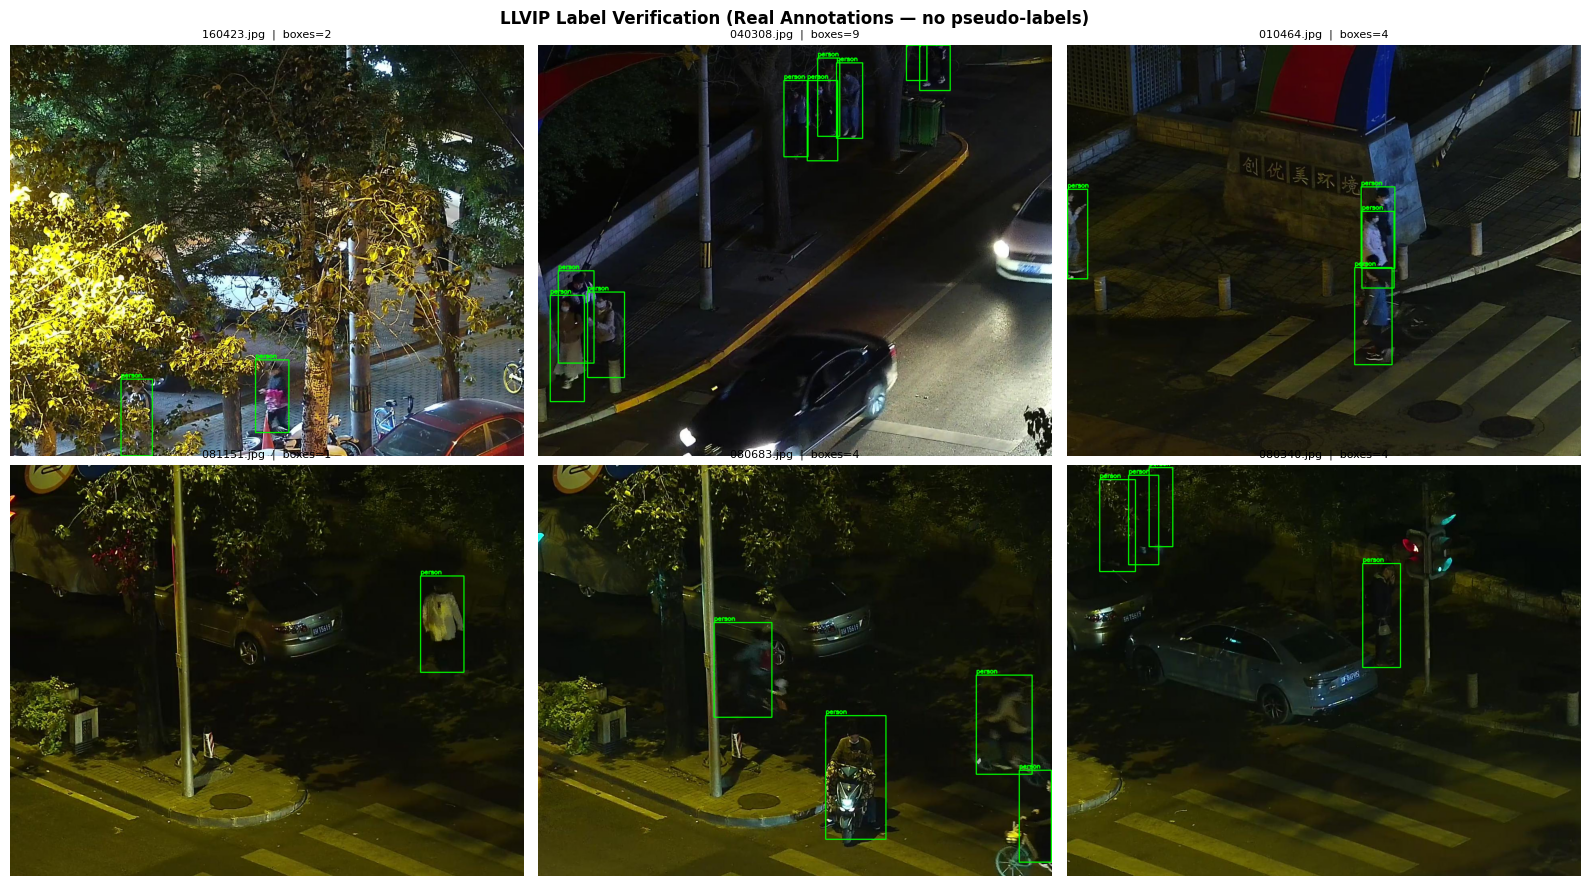

Total label files : 6000
Empty labels      : 1 (0.0%)  <- should be ~0% for LLVIP
With person boxes : 5999


In [18]:
import matplotlib.pyplot as plt
import cv2


def load_yolo_labels(label_path):
    out = []
    if not os.path.exists(label_path):
        return out
    for line in Path(label_path).read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) == 5:
            cls, xc, yc, bw, bh = parts
            out.append((int(cls), float(xc), float(yc),
                        float(bw), float(bh)))
    return out


def draw_yolo_boxes(img_rgb, boxes):
    h, w = img_rgb.shape[:2]
    out  = img_rgb.copy()
    for cls, xc, yc, bw, bh in boxes:
        x1 = int((xc - bw / 2) * w)
        y1 = int((yc - bh / 2) * h)
        x2 = int((xc + bw / 2) * w)
        y2 = int((yc + bh / 2) * h)
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(out, "person", (x1, max(0, y1 - 5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
    return out


sample_imgs = glob.glob(
    os.path.join(YOLO_OUT_ROOT, "images", "train", "*.*")
)
random.seed(SEED)
sample_imgs = random.sample(sample_imgs, min(6, len(sample_imgs)))

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, img_path in zip(axes.flatten(), sample_imgs):
    img   = cv2.imread(img_path)
    img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    lab   = os.path.join(YOLO_OUT_ROOT, "labels", "train",
                         Path(img_path).stem + ".txt")
    boxes = load_yolo_labels(lab)
    vis   = draw_yolo_boxes(img, boxes)
    ax.imshow(vis)
    ax.set_title(f"{Path(img_path).name}  |  boxes={len(boxes)}",
                 fontsize=8)
    ax.axis("off")

plt.suptitle(
    "LLVIP Label Verification (Real Annotations — no pseudo-labels)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

# Sanity stats
all_labs = glob.glob(
    os.path.join(YOLO_OUT_ROOT, "labels", "train", "*.txt")
)
empty = sum(
    1 for p in all_labs
    if Path(p).read_text(encoding="utf-8").strip() == ""
)
print(f"Total label files : {len(all_labs)}")
print(f"Empty labels      : {empty} "
      f"({100*empty/max(len(all_labs),1):.1f}%)  <- should be ~0% for LLVIP")
print(f"With person boxes : {len(all_labs) - empty}")

## 6) Check GPU

In [19]:
import sys
import torch

print("python :", sys.version)
print("torch  :", torch.__version__)
print("CUDA   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU    :", torch.cuda.get_device_name(0))
    print("VRAM   :",
          round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1),
          "GB")

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("DEVICE :", DEVICE)

python : 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
torch  : 2.10.0+cu126
CUDA   : True
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM   : 8.6 GB
DEVICE : 0


## 7) Fine-tune YOLOv8 on LLVIP

Key differences from the ExDark training:

| Parameter | ExDark run | LLVIP run | Reason |
|---|---|---|---|
| `imgsz` | 512 | **640** | LLVIP images are 1280x1024 — higher res captures more detail |
| `lr0` | 0.001 | **0.0005** | Real labels are stable — lower LR avoids overshooting |
| `epochs` | 25 | **30** | Larger dataset needs more steps to converge |
| `hsv_v` | 0.4 | **0.6** | More brightness variation bridges LLVIP to CCTV domain gap |
| `degrees` | 0 | **5** | Slight rotation robustness for different camera mount angles |

In [20]:
from ultralytics import YOLO
import torch

DEVICE   = 0 if torch.cuda.is_available() else "cpu"
IMG_SIZE = 640
EPOCHS   = 30
BATCH    = 8   # reduce to 4 if you get CUDA out-of-memory errors

print(f"Training : imgsz={IMG_SIZE}, epochs={EPOCHS}, batch={BATCH}, device={DEVICE}")
print(f"Dataset  : {DATA_YAML_PATH}")
print(f"Weights  : {BASE_WEIGHTS}")
print()

train_model = YOLO(BASE_WEIGHTS)

train_model.train(
    data    = DATA_YAML_PATH,
    imgsz   = IMG_SIZE,
    epochs  = EPOCHS,
    batch   = BATCH,
    device  = DEVICE,

    # Optimizer
    optimizer     = "AdamW",
    lr0           = 0.0005,
    cos_lr        = True,
    warmup_epochs = 3,

    # Regularisation
    patience = 10,
    amp      = True,

    # Augmentation
    # hsv_v=0.6 adds extra brightness variation so the model learns
    # to handle both LLVIP-style and CCTV-style dark conditions
    hsv_v        = 0.6,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    fliplr       = 0.5,
    degrees      = 5.0,
    close_mosaic = 5,   # disable mosaic in last 5 epochs for stable convergence

    workers  = 4,
    project  = os.path.join(YOLO_OUT_ROOT, "runs"),
    name     = "yolov8n_llvip_person",
)

BEST_PT = os.path.join(
    YOLO_OUT_ROOT, "runs", "yolov8n_llvip_person", "weights", "best.pt"
)
print("\nTraining complete.")
print(f"best.pt exists : {os.path.exists(BEST_PT)}")
print(f"best.pt path   : {BEST_PT}")

Training : imgsz=640, epochs=30, batch=8, device=0
Dataset  : runs/darkCondition_yolo\data.yaml
Weights  : yolov8n.pt

New https://pypi.org/project/ultralytics/8.4.21 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.250  Python-3.13.2 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=runs/darkCondition_yolo\data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, 

## 8) Plot Training Curves from results.csv

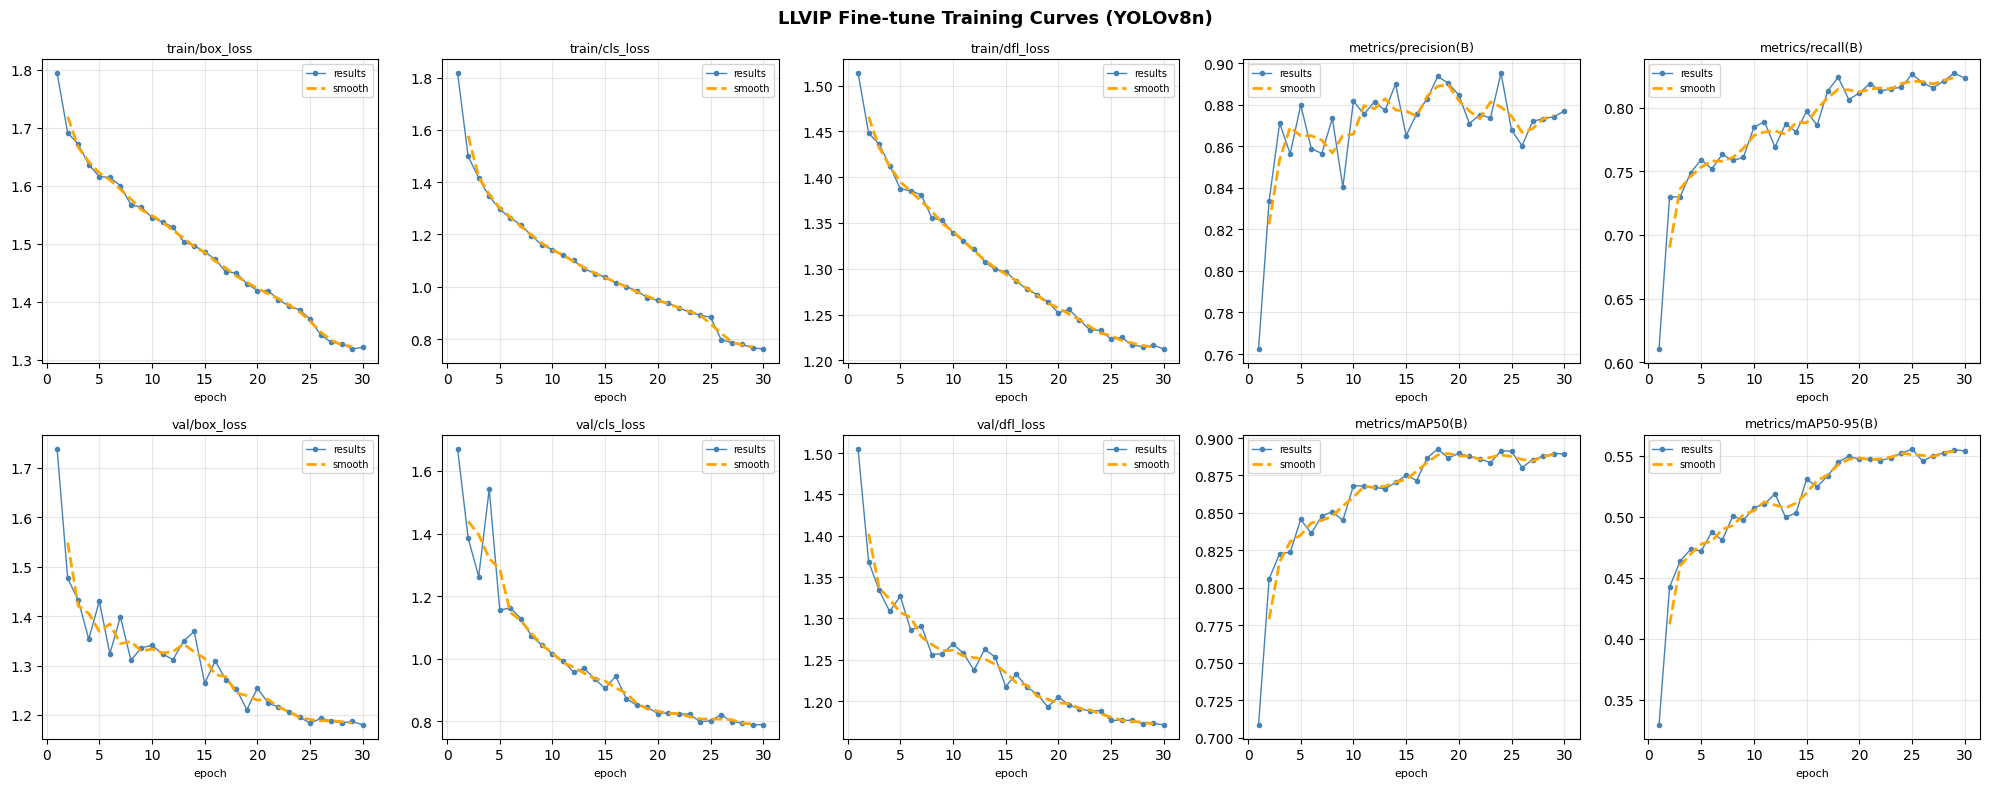

=== Final Epoch Metrics ===
  metrics/precision(B)          : 0.8769
  metrics/recall(B)             : 0.8234
  metrics/mAP50(B)              : 0.8894
  metrics/mAP50-95(B)           : 0.5541

=== Health Check ===
  mAP50=0.889 — strong result
  val/cls_loss gap = 0.027 — no significant overfitting


In [21]:
import pandas as pd
import matplotlib.pyplot as plt

RUN_DIR  = os.path.join(YOLO_OUT_ROOT, "runs", "yolov8n_llvip_person")
csv_path = os.path.join(RUN_DIR, "results.csv")

if not os.path.exists(csv_path):
    print("results.csv not found — has training finished?")
    print("Expected path:", csv_path)
else:
    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    epochs = df["epoch"]

    metrics_to_plot = [
        "train/box_loss", "train/cls_loss", "train/dfl_loss",
        "metrics/precision(B)", "metrics/recall(B)",
        "val/box_loss",   "val/cls_loss",   "val/dfl_loss",
        "metrics/mAP50(B)", "metrics/mAP50-95(B)",
    ]

    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    for ax, col in zip(axes.flatten(), metrics_to_plot):
        if col in df.columns:
            ax.plot(epochs, df[col], marker="o", markersize=3,
                    linewidth=1, label="results", color="steelblue")
            smooth = pd.Series(df[col]).rolling(3, center=True).mean()
            ax.plot(epochs, smooth, linewidth=2, linestyle="--",
                    color="orange", label="smooth")
            ax.set_title(col, fontsize=9)
            ax.set_xlabel("epoch", fontsize=8)
            ax.legend(fontsize=7)
            ax.grid(alpha=0.3)
        else:
            ax.set_visible(False)

    plt.suptitle("LLVIP Fine-tune Training Curves (YOLOv8n)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(RUN_DIR, "results_plot.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

    # Final metrics
    last = df.iloc[-1]
    print("=== Final Epoch Metrics ===")
    for m in ["metrics/precision(B)", "metrics/recall(B)",
              "metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
        if m in df.columns:
            print(f"  {m:<30}: {last[m]:.4f}")

    # Health checks
    print("\n=== Health Check ===")
    final_mAP = last.get("metrics/mAP50(B)", 0)
    if final_mAP > 0.85:
        print(f"  mAP50={final_mAP:.3f} — strong result")
    elif final_mAP > 0.70:
        print(f"  mAP50={final_mAP:.3f} — good result")
    else:
        print(f"  mAP50={final_mAP:.3f} — lower than expected, check loss curves")

    if "val/cls_loss" in df.columns and "train/cls_loss" in df.columns:
        gap = last["val/cls_loss"] - last["train/cls_loss"]
        if gap > 0.5:
            print(f"  val/cls_loss gap = {gap:.3f} — possible overfitting")
        else:
            print(f"  val/cls_loss gap = {gap:.3f} — no significant overfitting")

## 9) Validate Final Model on LLVIP Val Set

Runs `model.val()` to get official mAP on the held-out val split.
**These are the numbers to quote in your FYP results chapter.**

In [22]:
from ultralytics import YOLO

BEST_PT = os.path.join(
    YOLO_OUT_ROOT, "runs", "yolov8n_llvip_person", "weights", "best.pt"
)

if not os.path.exists(BEST_PT):
    print("best.pt not found — run Section 7 (training) first.")
else:
    print("Running validation on LLVIP val split...\n")
    val_model   = YOLO(BEST_PT)
    val_metrics = val_model.val(
        data  = DATA_YAML_PATH,
        imgsz = IMG_SIZE,
        device= DEVICE,
        conf  = 0.35,   # F1-optimal starting point — update from BoxF1_curve
    )

    print("\n" + "=" * 52)
    print("  VALIDATION RESULTS — LLVIP val split")
    print("=" * 52)
    print(f"  Precision  : {val_metrics.box.mp:.4f}")
    print(f"  Recall     : {val_metrics.box.mr:.4f}")
    print(f"  mAP@0.5    : {val_metrics.box.map50:.4f}")
    print(f"  mAP@0.5-95 : {val_metrics.box.map:.4f}")
    print("=" * 52)
    print()
    print("Comparison with ExDark pseudo-label run:")
    print("  ExDark: mAP@0.5=0.841  (487 images, pseudo-labels)")
    print(f"  LLVIP : mAP@0.5={val_metrics.box.map50:.3f}  "
          f"(6,000 images, real labels)")
    print()
    print("Next step: update FINETUNED_WEIGHTS in DarkCondition_Comparison.ipynb")
    print(f"  FINETUNED_WEIGHTS = '{BEST_PT}'")

Running validation on LLVIP val split...

Ultralytics 8.3.250  Python-3.13.2 torch-2.10.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 198.285.4 MB/s, size: 119.1 KB)
val: Scanning C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\darkCondition_yolo\labels\val.cache... 1500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1500/1500 1.8Mit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 94/94 8.3it/s 11.3s0.1s
                   all       1500       3477      0.893      0.817      0.878      0.556
Speed: 1.3ms preprocess, 2.3ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to C:\Users\jingy\OneDrive\Desktop\FYP\notebook\runs\detect\val12

  VALIDATION RESULTS — LLVIP val split
  Precision  : 0.8926
  Recall     : 0.8171
  mAP@0.5    : 0.8779
  mAP@0.5-95 : 0